# 1. MLP Implementation


In [1]:
# test cuda
import torch
print("CUDA Is Available:", torch.cuda.is_available())
# 强行在 5090 上跑一次 ReLU 激活函数，验证内核镜像是否匹配
x = torch.randn(2, 2, device='cuda')
print("ReLU Test Output:", torch.relu(x))

CUDA Is Available: True
ReLU Test Output: tensor([[0.1396, 1.2734],
        [0.0000, 0.0000]], device='cuda:0')


In [ ]:
%matplotlib inline
import torch
from torch import nn
from utils.train_model import train_net, sgd
from utils.get_data import get_data

# Initialize model parameters
n_input, n_output, n_hidden = 28*28, 10, 256
W1 = nn.Parameter(torch.randn(
    n_input, n_hidden, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(n_hidden, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    n_hidden, n_output, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(n_output, requires_grad=True))
params = [W1, b1, W2, b2]

# Activation function
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

# Define the model
def net(X):
    X = X.reshape(-1, W1.shape[0])
    H = relu(X @ W1 + b1)
    return H @ W2 + b2

# Loss function
loss = nn.CrossEntropyLoss(reduction='none')

num_epochs = 20
lr = 0.1
batch_size = 256
train_iter, test_iter = get_data(batch_size = batch_size)

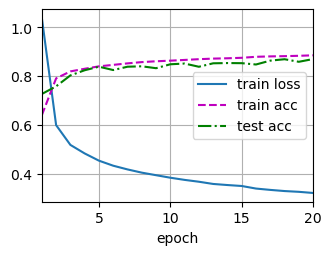

epoch 20, train loss 0.321, train acc 0.885, test acc 0.870


In [ ]:
train_net(net, train_iter, test_iter, loss, num_epochs, updater = lambda batch_size: sgd(params, lr, batch_size=batch_size))

# 2. Simple Implementation

In [4]:
%matplotlib inline
net_simple = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_input, n_hidden, bias = True),
    nn.ReLU(),
    nn.Linear(n_hidden, n_output, bias = True)
)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net_simple.apply(init_weights);
loss = nn.CrossEntropyLoss(reduction='none')

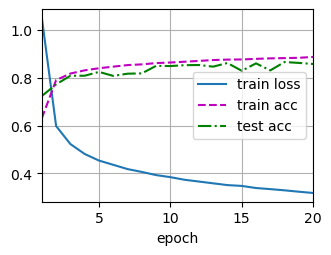

epoch 20, train loss 0.318, train acc 0.887, test acc 0.858


In [ ]:
train_net(net_simple, train_iter, test_iter, loss, num_epochs, updater = torch.optim.SGD(net_simple.parameters(), lr=lr))

# 3. Train with GPU

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('training on', device)

training on cuda


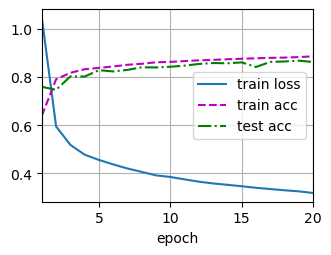

epoch 20, train loss 0.319, train acc 0.887, test acc 0.863


In [ ]:
net_simple_gpu = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_input, n_hidden, bias = True),
    nn.ReLU(),
    nn.Linear(n_hidden, n_output, bias = True)
)
net_simple_gpu.apply(init_weights);
net_simple_gpu.to(device)



train_net(net_simple_gpu, train_iter, test_iter, loss, num_epochs, updater = torch.optim.SGD(net_simple_gpu.parameters(), lr=lr), device=device)